In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
import os
from google.colab import files

file_name = "Netflixmoviedataset.csv"

if not os.path.exists(file_name):
  print(f"File '{file_name}' not found. Please upload it.")
  uploaded = files.upload()
  if file_name not in uploaded:
    print(f"'{file_name}' was not uploaded. Please upload the correct file.")
  else:
    df=pd.read_csv(file_name, lineterminator="\n")
    print(f"'{file_name}' uploaded and loaded successfully.")
else:
  df=pd.read_csv(file_name, lineterminator="\n")
  print(f"'{file_name}' found and loaded successfully.")

'Netflixmoviedataset.csv' found and loaded successfully.


In [81]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
        9837 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [83]:
df["Genre"].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [84]:
df.duplicated().sum()

np.int64(0)

In [85]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000




*   we have a dataframe consisting of 9827 rows and 9 columns

*   our dataset looks a bit tidy with** no null **bold text** **or **duplicated values**
    
    Release_Data column needs to be casted into date time and to extract only the year value

    Overview Original_language and posture_url wouldnot be so useful analysis ,so we all drop them

    there is noticable outlier in popularity  column

    vote_average better be categorised for proper analysis

    Genre column has comma seperated values and white spaces that needs to be handled and casted into category **Exploration**



In [86]:
df["Release_Date"]=pd.to_datetime(df["Release_Date"] , errors="coerce")
print(df["Release_Date"].dtypes)

datetime64[ns]


/tmp/ipykernel_12869/2869280790.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Release_Date"]=pd.to_datetime(df["Release_Date"] , errors="coerce")


In [87]:
df["Release_Date"]=df["Release_Date"].dt.year
df["Release_Date"].dtypes

dtype('float64')

In [88]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url\r
0,2021.0,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022.0,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022.0,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021.0,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021.0,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


Dropping the columns

In [89]:
cols=["Overview","Original_Language","Poster_Url\r"]

In [90]:
df.drop(cols, axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [91]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122,6.3,Thriller
3,2021.0,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793,7,"Action, Adventure, Thriller, War"


**Categorizing vote_Average columns**
We would cut the vote_average values and make 4 categories popular ,average ,below_avg ,not_popular to describe it more using categories_col() function provided above

In [92]:
def catigorize_col(df,col,labels):
  edges= (df[col].describe()["min"],
         df[col].describe()["25%"],
         df[col].describe()["50%"],
         df[col].describe()["75%"],
         df[col].describe()["max"])
  df[col]=pd.cut(df[col],edges,labels=labels, duplicates = "drop")
  return df

In [93]:
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')
df.dropna(subset=['Vote_Average'], inplace=True)

labels=['not_popular','below_avg','average','popular']
catigorize_col(df,'Vote_Average',labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [94]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022.0,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022.0,No Exit,2618.087,122,below_avg,Thriller
3,2021.0,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021.0,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [95]:
df["Vote_Average"].value_counts()

,count
Vote_Average,
not_popular,2467
popular,2450
average,2411
below_avg,2398


In [96]:
df.dropna(inplace=True)
df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


In [97]:
print(df['Genre'].head())

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object


we'd split genres into a list and then explode our dataframe to have only one genre per row for ezch movie

In [98]:
df["Genre"]=df["Genre"].str.split(', ')
df=df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022.0,The Batman,3827.658,1151,popular,Crime
4,2022.0,The Batman,3827.658,1151,popular,Mystery


casting column into category

In [99]:
df['Genre']=df['Genre'].astype('category')

df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25551 non-null  float64 
 1   Title         25551 non-null  object  
 2   Popularity    25551 non-null  float64 
 3   Vote_Count    25551 non-null  object  
 4   Vote_Average  25551 non-null  category
 5   Genre         25551 non-null  category
dtypes: category(2), float64(2), object(2)
memory usage: 849.4+ KB


In [101]:
df.nunique()

,0
Release_Date,100
Title,9414
Popularity,8087
Vote_Count,3265
Vote_Average,4
Genre,19


Data Visualization

In [102]:
sns.set_style('whitegrid')

# **What is the most frequent genre of movies released on Netflix**

```

```



In [103]:
df['Genre'].describe()

,Genre
count,25551
unique,19
top,Drama
freq,3715


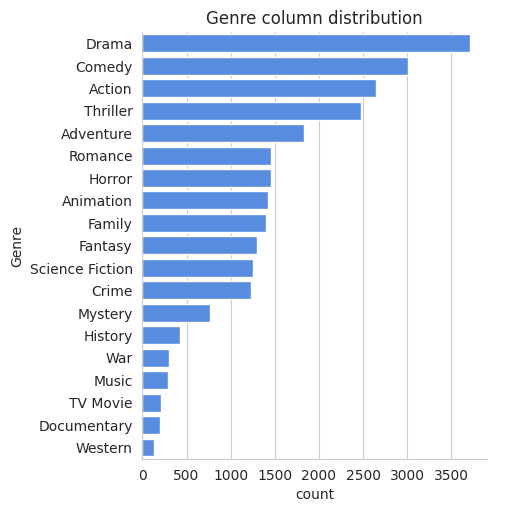

In [104]:
sns.catplot(y='Genre',data=df,kind='count',
            order=df['Genre'].value_counts().index,
            color='#4287f5')
plt.title("Genre column distribution")
plt.show()

# **Which has highest votes in vote avg column?**

In [105]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022.0,The Batman,3827.658,1151,popular,Crime
4,2022.0,The Batman,3827.658,1151,popular,Mystery


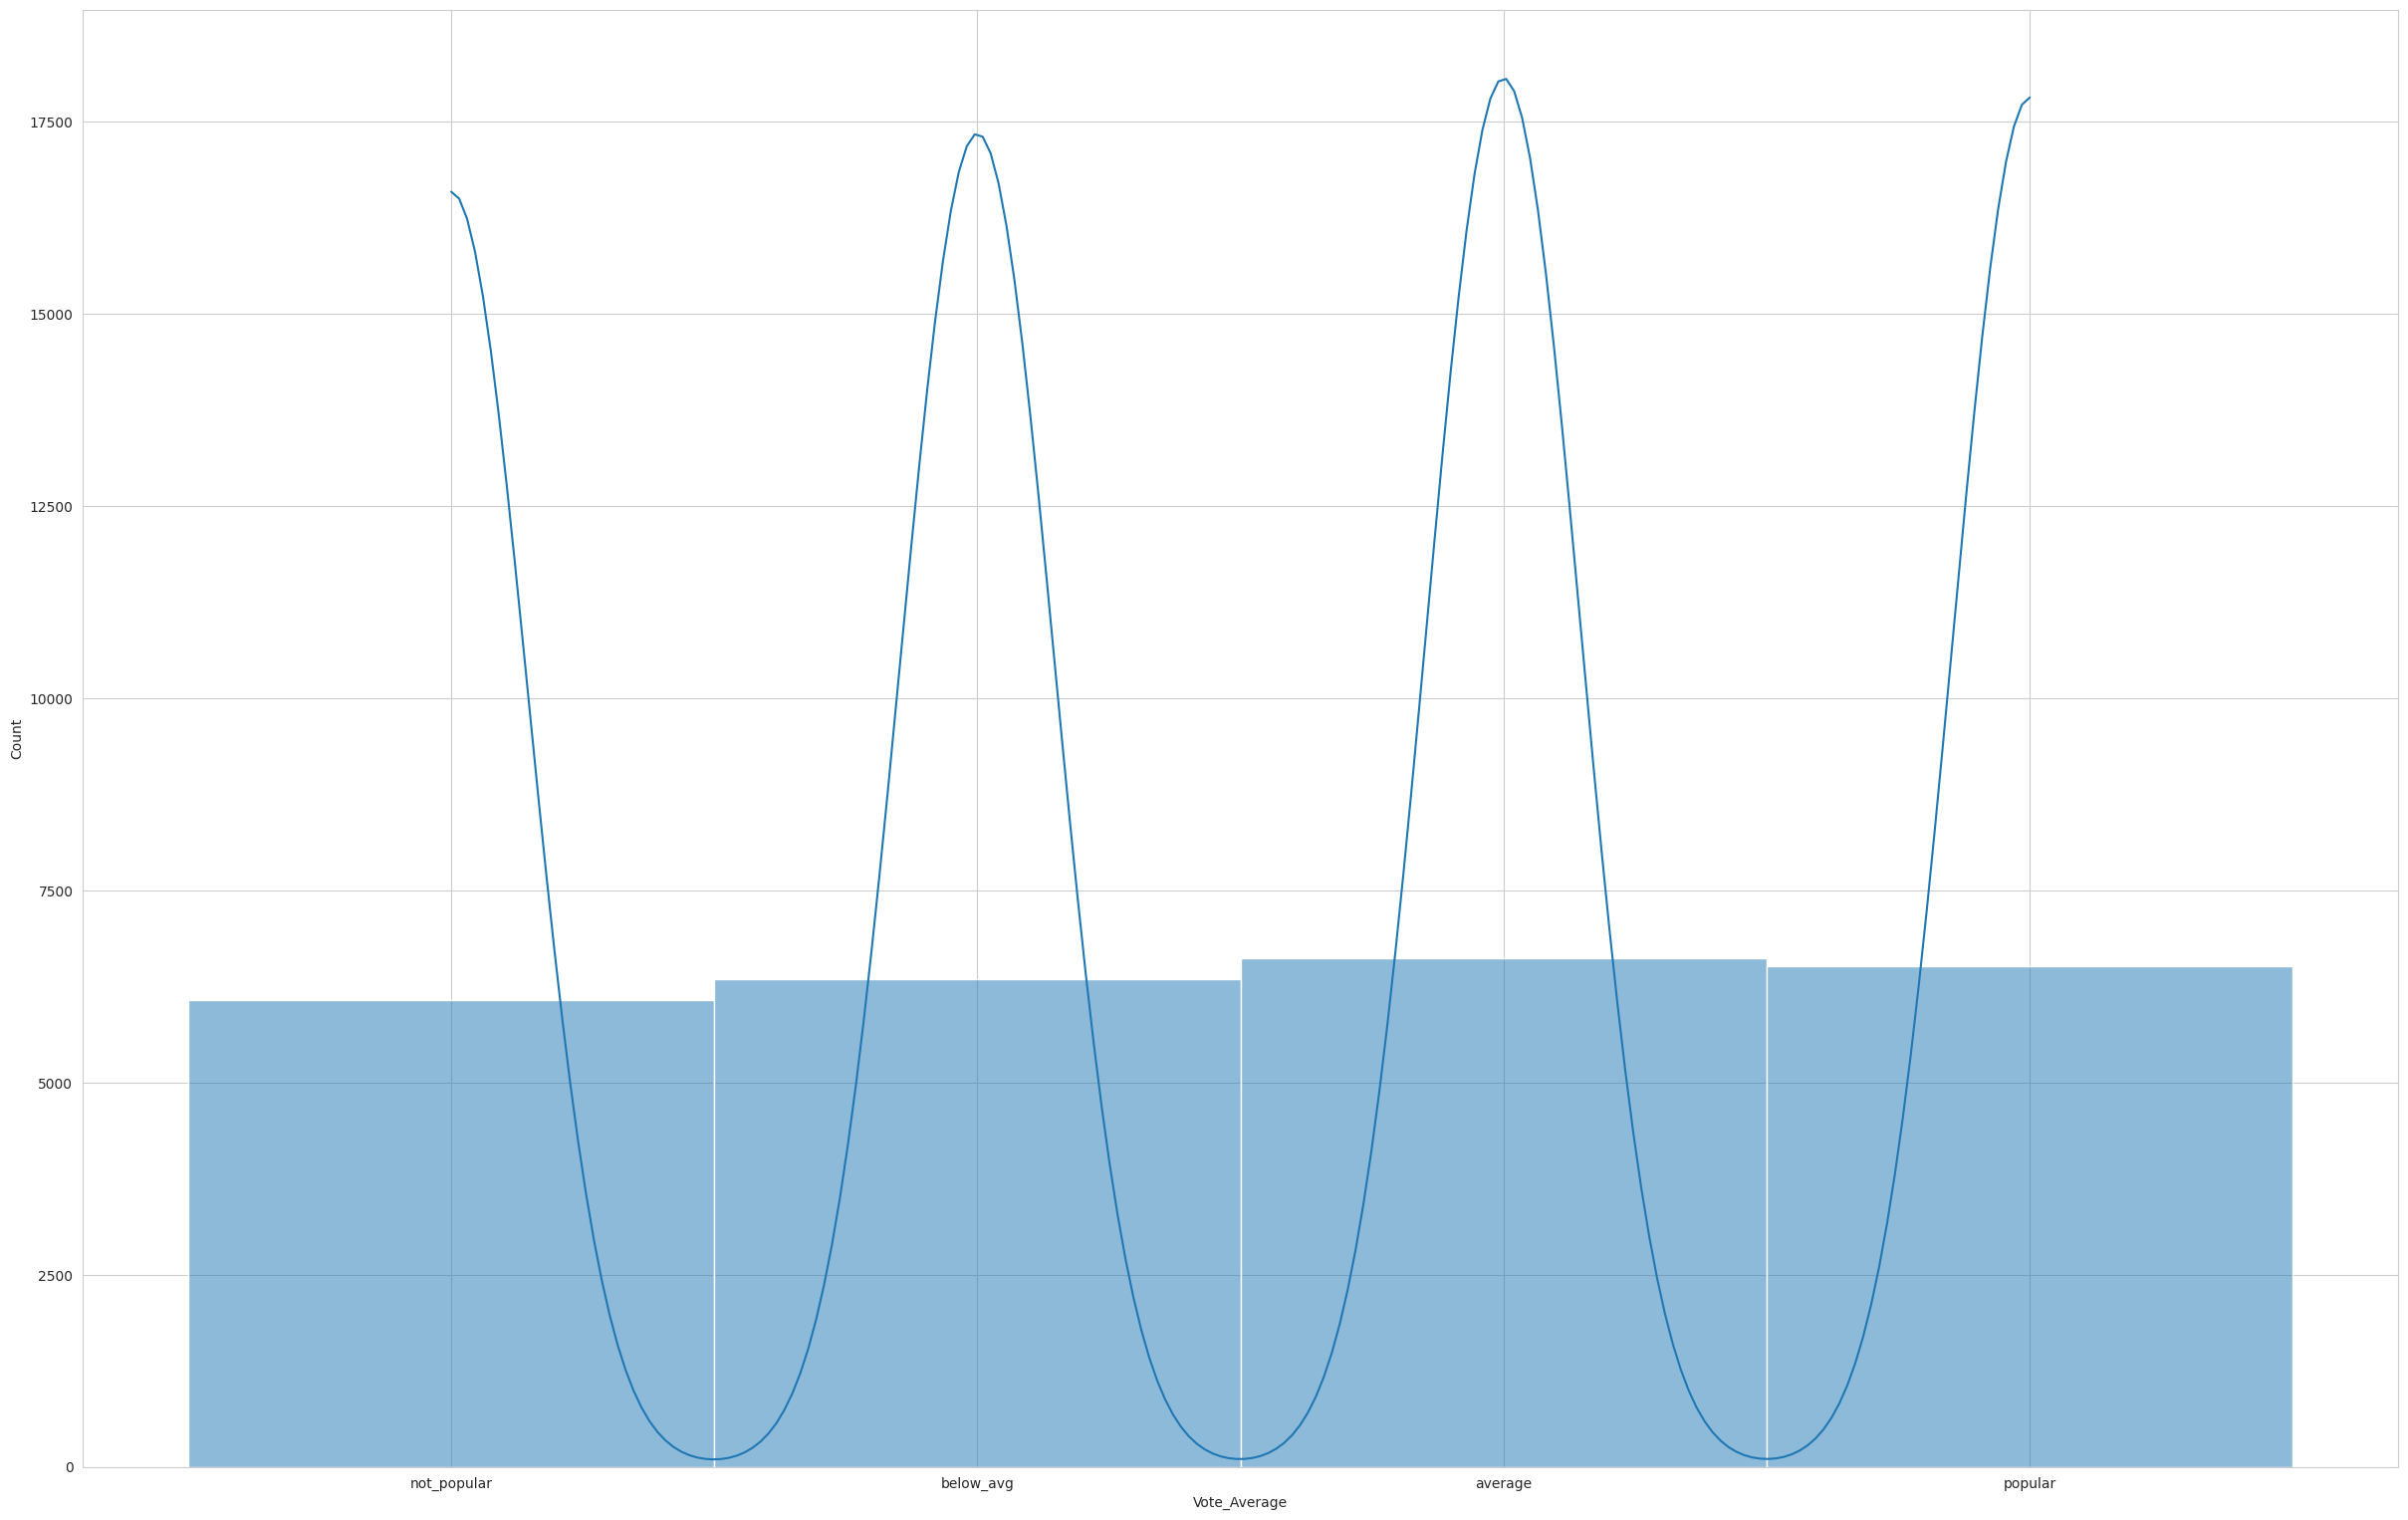

In [106]:
plt.figure(figsize=(30,19))
sns.histplot(df['Vote_Average'],bins=10,
             kde=True)
plt.show()

# **What movie got the highest popularity?what's its genre**

In [107]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021.0,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


# **What movie got the lowest popularity?what's its genre**

In [108]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25545,2021.0,The United States vs. Billie Holiday,13.354,152,average,Music
25546,2021.0,The United States vs. Billie Holiday,13.354,152,average,Drama
25547,2021.0,The United States vs. Billie Holiday,13.354,152,average,History
25548,1984.0,Threads,13.354,186,popular,War
25549,1984.0,Threads,13.354,186,popular,Drama
25550,1984.0,Threads,13.354,186,popular,Science Fiction


# **Which year has the most filmmed movies**

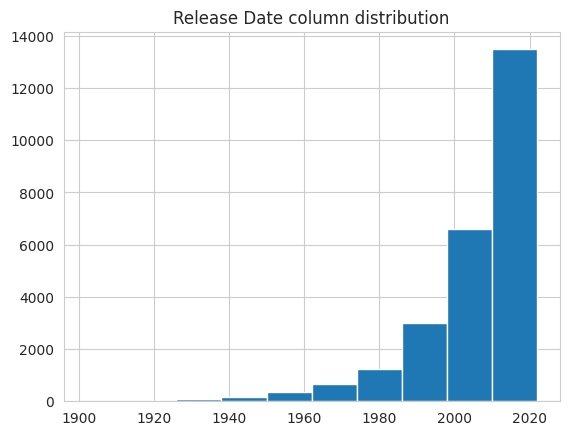

In [109]:
df['Release_Date'].hist()
plt.title("Release Date column distribution")
plt.show()

In [110]:
import zipfile

file_to_zip = 'Netflixmoviedataset.xlsx'
zip_file_name = 'Netflixmoviedataset.zip'

with zipfile.ZipFile(zip_file_name, 'w') as zipf:
    zipf.write(file_to_zip, arcname=file_to_zip)

print(f"'{file_to_zip}' has been successfully zipped into '{zip_file_name}'.")

'Netflixmoviedataset.xlsx' has been successfully zipped into 'Netflixmoviedataset.zip'.


In [111]:
import zipfile

file_to_zip_csv = 'Netflixmoviedataset.csv'
zip_file_name_csv = 'Netflixmoviedataset_processed.zip'

with zipfile.ZipFile(zip_file_name_csv, 'w') as zipf:
    zipf.write(file_to_zip_csv, arcname=file_to_zip_csv)

print(f"'{file_to_zip_csv}' has been successfully zipped into '{zip_file_name_csv}'.")

'Netflixmoviedataset.csv' has been successfully zipped into 'Netflixmoviedataset_processed.zip'.
